# Backtest what someone said, without hindsight

Two years of Jim Cramer's market calls on CNBC (`samples/cramer`: 2,091 statements, 1,169 links he drew between them, 779 calls settled by the price move at their horizon), analysed the way time series usually are: an equity curve for a trading rule, a track record over time, revisions. Each one rests on something a plain table of statements does not keep:

1. **A rule backtested as it would have run.** Every verdict carries the day it became known (`known_at`), so a rule that picks calls by his record so far reads only the record that existed then.
2. **His record as it stood each month.** The same dating replays the record on any day, the way economists read real-time data vintages instead of today's revised series.
3. **What his reversals did.** A replaced call is kept next to the call that replaced it (`SUPERSEDES`), so both can be scored.
4. **Whether reasons helped.** The links he drew and the verdicts are in one bundle, so it is one join.

Then two drill-downs to the statements behind the numbers, and one question to a model with the same data as its context, every cited line traced back to the recording.

Every chart is SQL in DuckDB over the Parquet profile with the macro pack (`duckdb/factblock.sql`). The analysis lives in [`views.py`](views.py) and returns its finding as the title, the rows behind every mark with their FactBlock ids, and a Vega-Lite spec, so the same view renders here, in a web page, or as an image in a chat answer.

In [1]:
import os, re, sys
from IPython.display import display, Markdown
import factblock
sys.path.insert(0, ".")
import views

BRAIN = "../../samples/cramer"
AS_OF = "2026-09-10"                    # read everything known by this day
con, pq = views.connect(BRAIN)          # a Parquet copy of the bundle + the macro pack

def show(v):
    """Render a view or a factblock.timeline: interactive Vega-Lite in Jupyter, a PNG where only images render (GitHub, chat)."""
    spec, title = (v.spec(), v.title) if hasattr(v, "spec") else (v["spec"], v["title"])
    bundle = {"application/vnd.vegalite.v5+json": spec, "text/plain": title}
    try:
        import vl_convert as vlc
        bundle["image/png"] = vlc.vegalite_to_png(spec, scale=1.5)
    except ImportError:
        pass
    display(bundle, raw=True)

factblock.__version__

'1.0.0a7'

## 1. A rule backtested as it would have run

The rule: follow his calls (long on up, short on down) only on subjects where at least half of his 3+ settled calls came true. Orange runs it the way a table of final outcomes allows: his record per subject is read from every verdict, including ones that did not exist when the call was made. Blue runs it as of each call: only verdicts known before the call. Grey follows every call. The lines are the running average return per call, by verdict date.

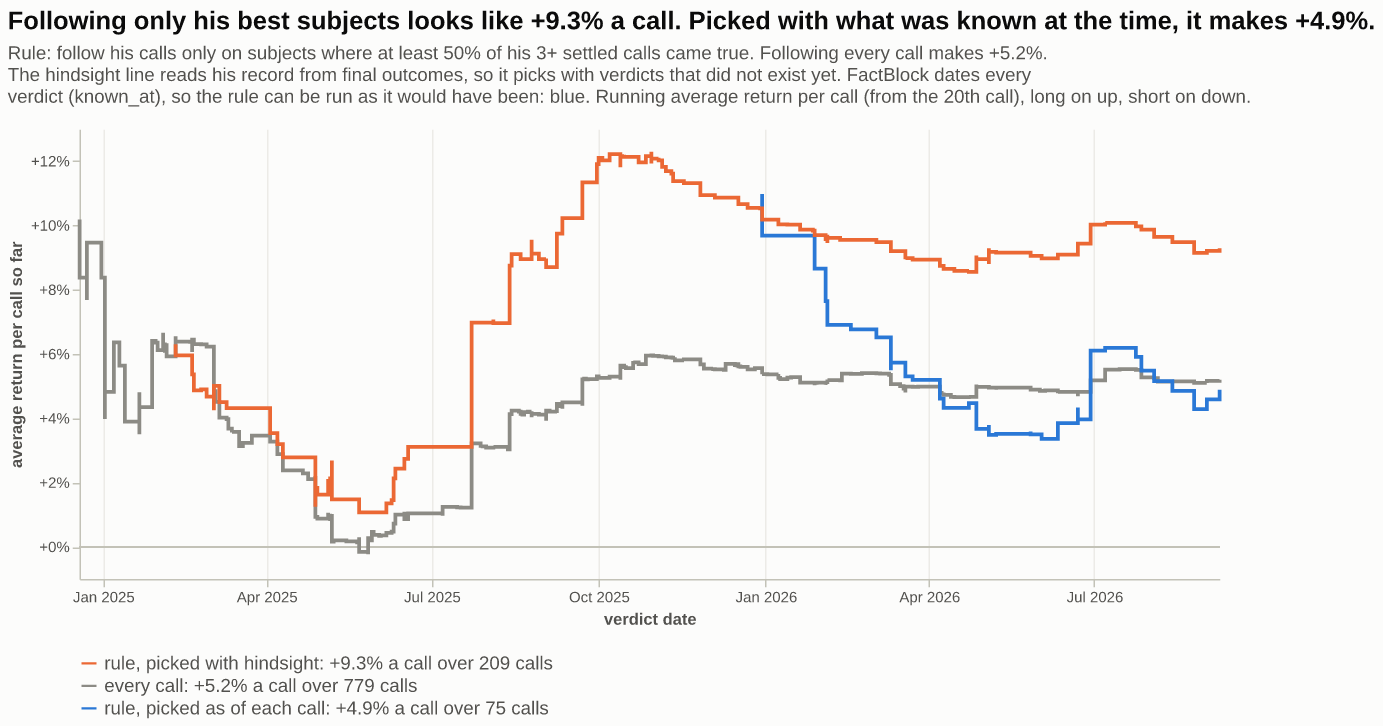

{'every call': (779, '+5.20%'),
 'rule, picked as of each call': (75, '+4.89%'),
 'rule, picked with hindsight': (209, '+9.29%')}

In [2]:
v = views.backtest(con, pq, AS_OF)
show(v)
{k: (s["calls"], f"{s['per_call']:+.2%}") for k, s in v["summary"].items()}

## 2. How good was his record at the time?

Blue: on the first of each month, the share of his settled calls that had come true, using only the verdicts known that day. Orange: the same day, scored the way a backtest scores it from a table of final outcomes, with every verdict known today. The bars underneath are the verdicts the orange line uses that did not exist yet.

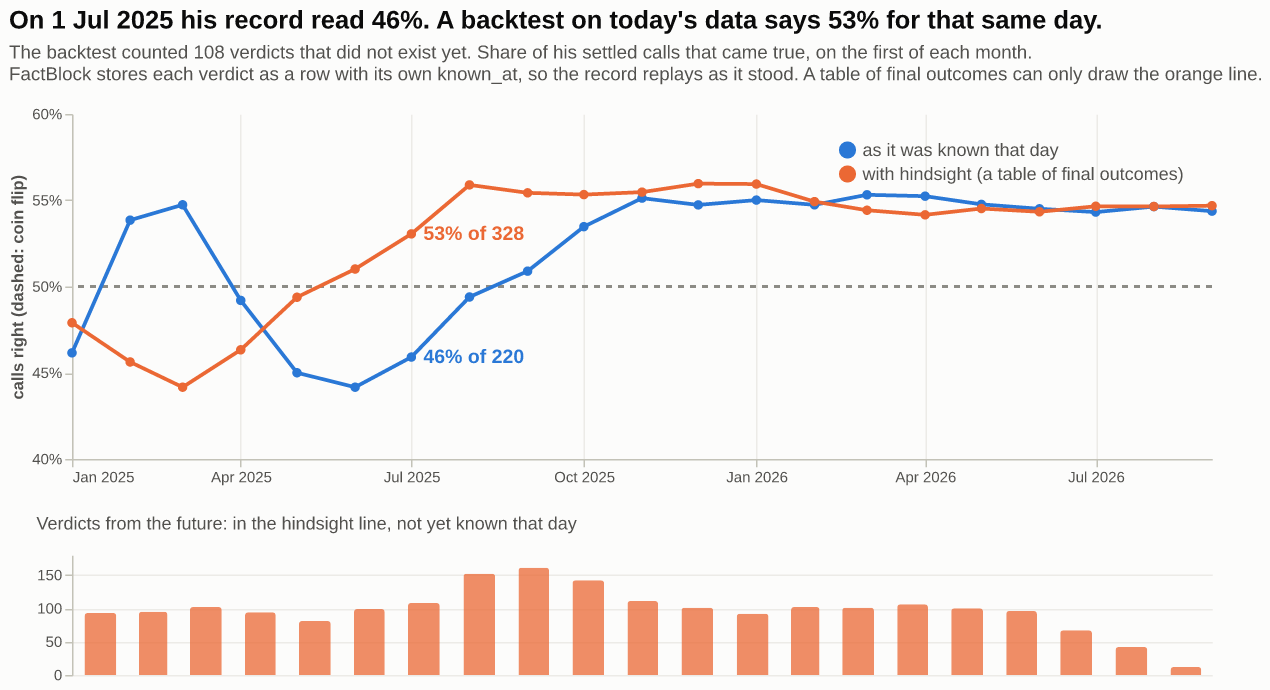

1 Jul 2025: known 220 verdicts, 45.9% right; hindsight 328 verdicts, 53.0% right


In [3]:
v = views.track_record(con, pq, AS_OF)
show(v)
r = next(r for r in v["rows"] if r["day"] == "2025-07-01")
print(f"1 Jul 2025: known {r['known']} verdicts, {r['known_rate']:.1%} right; hindsight {r['hindsight']} verdicts, {r['hindsight_rate']:.1%} right")

## 3. Did changing his mind help?

108 times he made a call and later made the opposite call on the same thing; the new block `SUPERSEDES` the old one and both stay in the bundle. Where both have a verdict, did the reversal fix a wrong call or break a right one? Hover a bar for the [old, new] FactBlock id pairs.

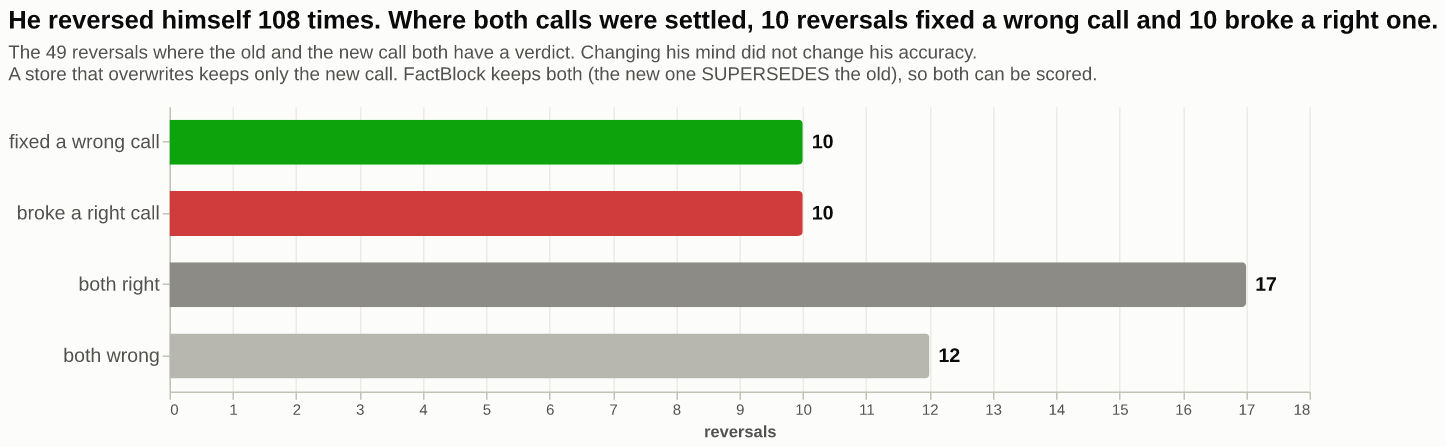

fixed a wrong call
  old  [baba020de4fe84cb]  2025-02-25  Investors should avoid owning the nuclear fission company Oklo.
  new  [a106b3b283494603]  2025-06-24  Oklo is a good investment because the nuclear power sector is making a comeback.
broke a right call
  old  [7bc2ad2eec19e3ab]  2025-01-25  There is no reason to own Texas Instruments stock.
  new  [0d3325178b7b0fb6]  2025-07-03  Texas Instruments is a recommended semiconductor stock to own.


In [4]:
v = views.reversals(con, pq, AS_OF)
show(v)
# one reversal of each kind: both calls stay in the bundle, so both can be scored
by_id = {n["id"]: n for n in factblock.Bundle(BRAIN).nodes}
pairs = {tuple(p): r["outcome"] for r in v["rows"] for p in r["pairs"]}
for old, new in (("baba020de4fe84cb", "a106b3b283494603"), ("7bc2ad2eec19e3ab", "0d3325178b7b0fb6")):
    print(pairs[(old, new)])
    for label, i in (("  old", old), ("  new", new)):
        print(f"{label}  [{i}]  {by_id[i]['asserted_at'].date()}  {by_id[i]['statement']}")

## 4. Were his reasoned calls better?

Settled calls split by whether he linked a reason to them (`CAUSES`, `CONTRIBUTING_FACTOR`, `TRIGGERS`, `SUPPORTS`). The links are his own, **recorded, not verified**: a `CAUSES` edge says he said one thing causes another. Only the verdict is checked.

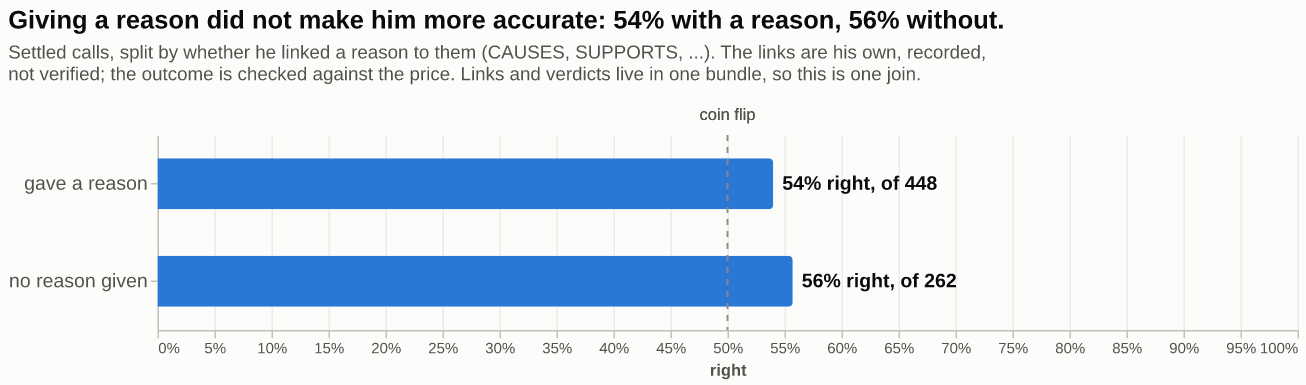

[('gave a reason', 448, 0.54), ('no reason given', 262, 0.557)]

In [5]:
v = views.reasons(con, pq, AS_OF)
show(v)
[(r["calls"], r["settled"], round(r["hit_rate"], 3)) for r in v["rows"]]

## Drill down: every call on the market, over the market

`factblock.timeline` is the library's reusable view for this: one bar per statement from when it was said to when it was replaced, judged or due; with a numeric series, each call as a point where it was said, coloured by what became of it, the settled ones labelled. Read as of 30 June 2025, it draws only what was known that day, including the series. The S&P 500 comes from FRED and is downloaded here rather than shipped, because the index is licensed.

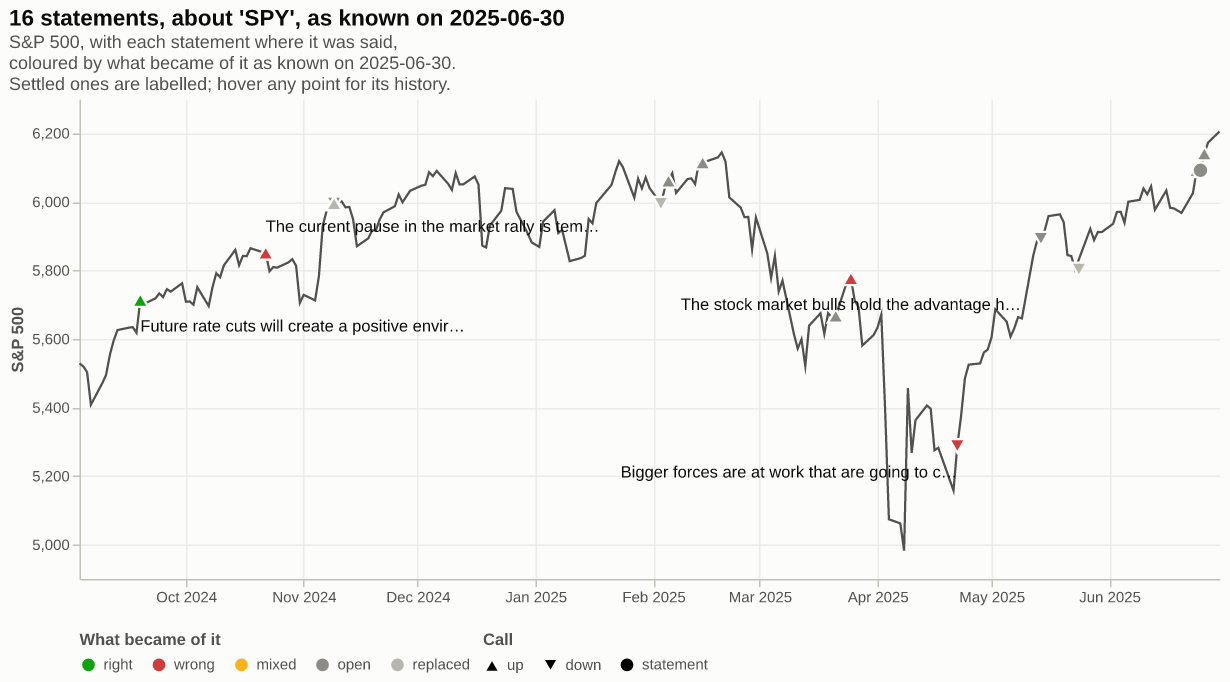

<Timeline as of 2025-06-30: 16 statements, 25 events, with S&P 500>
['2024-10-22  The current pause in the market rally is temporary and will las…', '2025-03-25  The stock market bulls hold the advantage heading into April an…', '2025-04-22  Bigger forces are at work that are going to crush the entire ma…']


In [6]:
import tempfile, urllib.request
sp500 = os.path.join(tempfile.gettempdir(), "sp500.csv")
if not os.path.exists(sp500):
    urllib.request.urlretrieve("https://fred.stlouisfed.org/graph/fredgraph.csv?id=SP500&cosd=2024-09-01", sp500)
t = factblock.timeline(BRAIN, "2025-06-30", "SPY", limit=20).with_series(sp500, "S&P 500")
show(t)
print(t)
print([c["lane"] for c in t.claims if c["status"] == "wrong"])

## Drill down: what one call rested on

21 March 2025, weeks before the April tariff sell-off: "The stock market is positioned to move higher." On the left, the reasons he gave; on the right, what he said next, settled as did not.

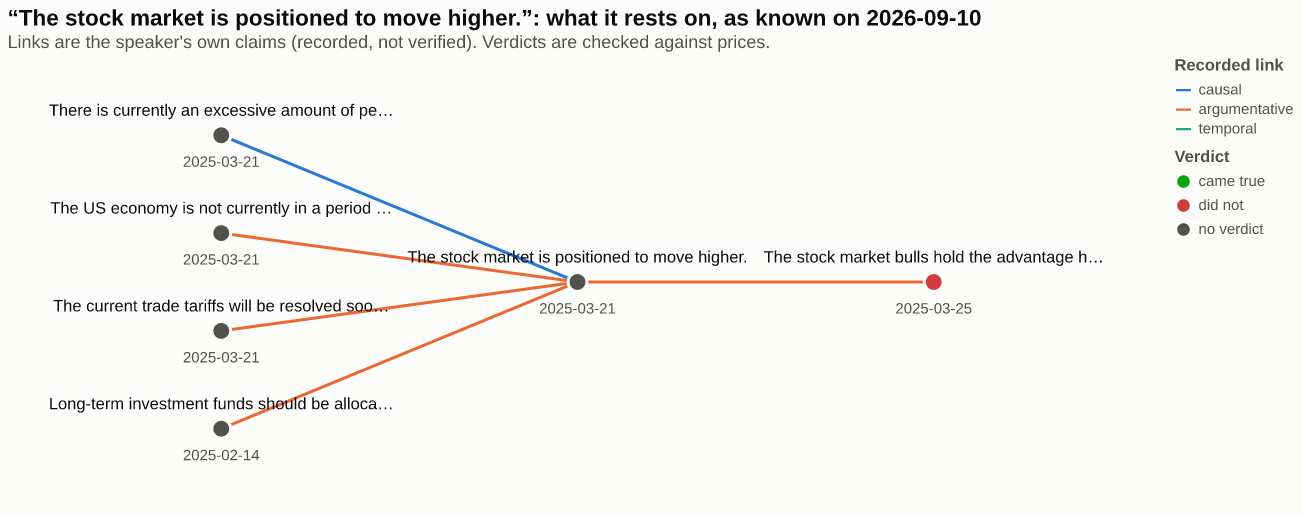

554789ad805f66cb -SUPPORTS-> fdc79a63b9b44a7f   (recorded by the speaker, not verified)
7c7f9d08e8c249e9 -SUPPORTS-> fdc79a63b9b44a7f   (recorded by the speaker, not verified)
909c01b4436033df -CAUSES-> fdc79a63b9b44a7f   (recorded by the speaker, not verified)
a90414c86ab67dfe -SUPPORTS-> fdc79a63b9b44a7f   (recorded by the speaker, not verified)
fdc79a63b9b44a7f -SUPPORTS-> ba4c1a04d78f5848   (recorded by the speaker, not verified)


In [7]:
v = views.evidence(con, pq, "fdc79a63b9b44a7f", AS_OF)
show(v)
for l in v["links"]:
    print(f"{l['source_id']} -{l['edge_type']}-> {l['target_id']}   ({l['basis']})")

### The same data in plain SQL

The views are ordinary SQL over the macro pack. Here is one query of your own: the hit rate of settled calls per subject, as known on two different days. Before a call's horizon passes its verdict does not exist yet, so the earlier read has fewer settled calls. This is the as-of rule doing its job, not missing data.

In [8]:
q = '''
SELECT json_extract_string(n.payload, '$.asset') AS subject,
       count(*) AS settled, round(avg((v.outcome = 'came_true')::INT), 2) AS hit_rate
  FROM read_parquet(? || '/nodes.parquet') n
  JOIN factblock_verdicts(?, factblock_day(?)) v ON v.target_id = n.id
 WHERE json_extract_string(n.payload, '$.asset') IN ('SPY', 'NVDA', 'AAPL', 'PLTR')
 GROUP BY 1 ORDER BY 1'''
for day in ("2025-06-01", AS_OF):
    print(day, con.execute(q, [pq, pq, day]).fetchall())

2025-06-01 [('AAPL', 5, 0.4), ('NVDA', 5, 0.2), ('PLTR', 4, 1.0), ('SPY', 3, 0.33)]
2026-09-10 [('AAPL', 10, 0.7), ('NVDA', 18, 0.61), ('PLTR', 15, 0.8), ('SPY', 12, 0.5)]


## Ask a model, then check the source

The question is asked as of 24 March 2025. `factblock.context(..., ids=True)` gives the model only what was known that day, one line per statement with its id. The model is told to cite ids, and each cited id goes back to its recording.

Set `OPENAI_API_KEY` or `GEMINI_API_KEY` to get a real answer; without a key the cell prints the prompt the model would get. `views.pick()` chooses the chart that fits the question, which is what a chat answer would attach.

In [9]:
def ask_model(prompt):
    if os.environ.get("OPENAI_API_KEY"):
        from openai import OpenAI
        r = OpenAI().chat.completions.create(model=os.environ.get("OPENAI_MODEL", "gpt-4.1-mini"), messages=[{"role": "user", "content": prompt}])
        return r.choices[0].message.content
    if os.environ.get("GEMINI_API_KEY"):
        from google import genai
        return genai.Client().models.generate_content(model=os.environ.get("GEMINI_MODEL", "gemini-2.5-flash"), contents=prompt).text
    return None

question = "Is Cramer bullish on the stock market right now, and why?"
asked = "2025-03-24"
print("chart for this question:", views.pick(question))

ctx = factblock.context(BRAIN, "stock market higher", as_of=asked, ids=True, limit=8)
prompt = (f"Today is {asked}. Answer from these notes only, and cite the [id] of every note you use.\n\n"
          f"{ctx}\n\nQuestion: {question}")
answer = ask_model(prompt)
print(answer or "(no model key set; this is the prompt the model would get)\n\n" + prompt)

chart for this question: evidence
(no model key set; this is the prompt the model would get)

Today is 2025-03-24. Answer from these notes only, and cite the [id] of every note you use.

- [fdc79a63b9b44a7f] 2025-03-21 Jim Cramer: The stock market is positioned to move higher. (source: Unrelenting market negativity bringing about 'real but ignored value', says Jim Cramer)
- [d58f18a907b63a18] 2025-03-12 Jim Cramer: The stock market has an underlying desire to go higher. (source: Pres. Trump says he's not focused on the stock market, says Jim Cramer)
- [51d673dee38eb6a4] 2024-12-17 Jim Cramer: Retail investor participation in the stock market is at an all-time high. (source: Tesla's move since the election is one for the ages, says Jim Cramer)
- [487ae337ab9ba268] 2024-10-31 Jim Cramer: The current market dips are a buying opportunity in high-quality stocks that investors should act on starting tomorrow. (source: It's insane how frightened shareholders can get, says Jim Cramer)
  ended 

In [10]:
# every id the answer cites (or, without a model, every id in the context), back to the recording
b = factblock.Bundle(BRAIN)
by_id = {n["id"]: n for n in b.nodes}
for i in dict.fromkeys(re.findall(r"\[([0-9a-f]{16})\]", answer or ctx)):
    p = by_id[i].get("payload") or {}
    print(f"[{i}] {by_id[i]['statement']}")
    print(f"    quote:  \"{p.get('quote', '')[:110]}\"")
    print(f"    source: {p['source']['url']}\n")

[fdc79a63b9b44a7f] The stock market is positioned to move higher.
    quote:  "You can see that stocks want to go higher."
    source: https://www.youtube.com/watch?v=10ZTB57CcDA&t=70s

[d58f18a907b63a18] The stock market has an underlying desire to go higher.
    quote:  "But you can see just for a second when the Canadians got constructive that this market truly does want to go h"
    source: https://www.youtube.com/watch?v=VJUaA9_tBys&t=148s

[51d673dee38eb6a4] Retail investor participation in the stock market is at an all-time high.
    quote:  "FIRST THE PUBLIC IS BACK FROM THE STOCK MARKET, BIGGER THAN EVER."
    source: https://www.youtube.com/watch?v=w9h0MsnpmBk&t=84s

[487ae337ab9ba268] The current market dips are a buying opportunity in high-quality stocks that investors should act on starting tomorrow.
    quote:  "let the sellers have their way today but you can start buying tomorrow It's kind of my mantra"
    source: https://www.youtube.com/watch?v=du6nWXgDbFk&t=102s

[6f

A day later he added "The stock market bulls hold the advantage heading into April and beyond." Read it on 26 March and it is an open call; read it on 10 April and it has ended, settled as **did not** on 3 April by the price at its horizon. Nothing was edited in between: a resolution row became visible. A model asked on each day gets exactly what was known that day.

In [11]:
print(factblock.context(BRAIN, "bulls advantage April", as_of="2025-03-26", ids=True, limit=1))
print()
print(factblock.context(BRAIN, "bulls advantage April", as_of="2025-04-10", ids=True, limit=1))

- [ba4c1a04d78f5848] 2025-03-25 Jim Cramer: The stock market bulls hold the advantage heading into April and beyond. (due 2025-04-02; source: Cramer on markets: The bulls and the president hold the cards)
(as of 2025-03-26)

- [ba4c1a04d78f5848] 2025-03-25 Jim Cramer: The stock market bulls hold the advantage heading into April and beyond. (source: Cramer on markets: The bulls and the president hold the cards)
  ended 2025-04-02
  verdict: did_not (decided 2025-04-03 by process:factagora-influencer-backtest/0.1)
(as of 2025-04-10)


## Use your own data

Each view needs one thing from your data: the backtest needs verdict rows with a `value` holding the call's `return` (as `samples/cramer` has), the track record needs verdict rows, reversals need `replaces`, reasons need links, and the market drill-down needs a subject and a direction. Start from [`template.csv`](template.csv), one row per call or verdict:

| column | meaning |
|---|---|
| `id` | your id for the call |
| `kind` | `prediction` |
| `said_at` | when it was said |
| `due` | the horizon (optional) |
| `text` | the statement |
| `asset` | the subject the views group by |
| `direction` | `up` or `down` |
| `speaker`, `source` | who said it, and where (a URL makes the marks clickable) |
| `replaces` | the id of an earlier call this one supersedes (optional) |
| `target`, `outcome`, `decided_at` | a verdict row: `came_true` or `did_not` for the call `target` |

```bash
factblock import my-calls.csv --backfill -o my-brain/
```

Then set `BRAIN = "my-brain"` at the top and run the notebook again. Causal and argumentative links (view 4 and the second drill-down) come from `factblock extract` on the transcripts, or from your own `edges.jsonl` rows.